# 01 · NF-HEDM orientation / calibration deep-dive

`midas-nf-fitorientation` is the differentiable PyTorch replacement for
the three NF-HEDM C executables:

| C executable | Python driver |
| --- | --- |
| `FitOrientationOMP` | `fit_orientation_run` |
| `FitOrientationParameters` | `fit_parameters_run` (single-voxel calibration) |
| `FitOrientationParametersMultiPoint` | `fit_multipoint_run` (cluster calibration) |

This notebook opens the box and shows the **mechanics those drivers
wrap**, on the bundled **Au** NF example, CPU only:

1. Load the bundled `SpotsInfo.bin` / `OrientMat.bin` / `grid.txt` /
   `hkls.csv` (the same precomputed artefacts the integration test uses).
2. Build the differentiable forward model.
3. Screen one voxel for candidate orientations.
4. Refine the orientation with L-BFGS over the Gaussian-splat soft
   overlap — the same kernel the calibration drivers run, but exposed
   step by step.

The bundled Au example ships its precomputed binaries in
`NF_HEDM/Example/sim/`, so this notebook needs **no C build and no
forward simulation** — it reads them directly.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')   # macOS libomp guard

import math
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from midas_nf_fitorientation import __version__, parse_paramfile
from midas_nf_fitorientation.io import read_grid, read_orientations, read_hkls
from midas_nf_fitorientation.obs_volume import ObsVolume
from midas_nf_fitorientation.screen import screen, orientmat_to_euler_zxz
from midas_nf_fitorientation.soft_overlap import (
    build_forward_model, soft_overlap_loss, auto_sigma_px,
)
from midas_nf_fitorientation.reparam import TanhBox
from midas_nf_fitorientation.fit_kernel import LBFGSConfig, run_lbfgs

DEVICE = torch.device('cpu')
DTYPE = torch.float64
print('midas-nf-fitorientation', __version__, '| torch', torch.__version__, '| device cpu')

midas-nf-fitorientation 0.3.1 | torch 2.11.0 | device cpu


## 1. Locate the bundled Au example

`MIDAS/NF_HEDM/Example/sim/` ships:

* `test_ps_au.txt` — the parameter file (geometry, lattice, ring/HKL config).
* `SpotsInfo.bin` — the observed spot mask (output of `midas-nf-preprocess`).
* `OrientMat.bin` / `Key.bin` / `DiffractionSpots.bin` — the candidate
  orientation set + their predicted spots.
* `grid.txt` — the voxel grid.
* `hkls.csv` — the ring/HKL table.

In [2]:
MIDAS_HOME = Path(os.environ.get('MIDAS_HOME') or Path.home() / 'opt' / 'MIDAS')
SIM = MIDAS_HOME / 'NF_HEDM' / 'Example' / 'sim'
PARAM = SIM / 'test_ps_au.txt'
assert PARAM.exists(), f'param not found: {PARAM} (set $MIDAS_HOME)'
for f in ['SpotsInfo.bin', 'OrientMat.bin', 'Key.bin', 'grid.txt', 'hkls.csv']:
    p = SIM / f
    print(f'{f:22s} {"OK " if p.exists() else "MISSING"} '
          f'{p.stat().st_size if p.exists() else 0:>14,} bytes')

SpotsInfo.bin          OK   1,509,949,440 bytes
OrientMat.bin          OK             288 bytes
Key.bin                OK              32 bytes
grid.txt               OK         164,302 bytes
hkls.csv               OK          37,415 bytes


## 2. Parse params + load the calibration inputs

`parse_paramfile` reads the C-style param file into a `FitParams`. The
`out_dir` it resolves (the `DataDirectory` line) is where all binaries
live.

In [3]:
p = parse_paramfile(str(PARAM))
out_dir = Path(p.out_dir)
print('out_dir          :', out_dir)
print('nDistances       :', p.n_distances)
print('frames/distance  :', p.n_frames_per_distance)
print('detector pixels  :', p.n_pixels_y, 'x', p.n_pixels_z, '| px (um):', p.px)
print('Lsd (per dist)   :', p.Lsd)
print('orient tol (deg) :', p.orient_tol, '| MinFracAccept:', p.min_frac_accept)

grid = read_grid(out_dir, p.grid_file_name)
orientations = read_orientations(out_dir)
hkl = read_hkls(out_dir)
if p.rings_to_use:
    hkl = hkl.filter_rings(p.rings_to_use)
print()
print('voxels in grid       :', grid.n_voxels)
print('candidate orientations:', orientations.matrices.shape[0])
print('HKLs after ring filter:', hkl.hkls_int.shape[0])

out_dir          : /Users/hsharma/opt/MIDAS/NF_HEDM/Example/sim
nDistances       : 2
frames/distance  : 1440
detector pixels  : 2048 x 2048 | px (um): 1.48
Lsd (per dist)   : [8289.154576, 10290.724494]
orient tol (deg) : 2.0 | MinFracAccept: 0.04

voxels in grid       : 3456
candidate orientations: 4
HKLs after ring filter: 258


## 3. Observed-spot volume + forward model

`ObsVolume.from_spotsinfo` reads `SpotsInfo.bin`. For the differentiable
Gaussian-splat overlap we need the **dense** floating-point storage
(`packed=False`) — the packed-bit storage is only for the boolean
hard-overlap path.

`build_forward_model` wraps `midas_diffract.HEDMForwardModel`: given an
orientation + voxel position it predicts where each HKL's diffraction
spots land on the detector stack.

In [4]:
obs = ObsVolume.from_spotsinfo(
    out_dir / 'SpotsInfo.bin',
    n_distances=p.n_distances,
    n_frames=p.n_frames_per_distance,
    n_y=p.n_pixels_y, n_z=p.n_pixels_z,
    device=DEVICE, dtype=torch.float32,
    packed=False,                       # dense storage for the soft path
)
model = build_forward_model(
    p, hkl.hkls_int.astype(np.float64),
    device=DEVICE, dtype=DTYPE,
    hkls_cart=hkl.hkls_cart.astype(np.float64),
)
print('ObsVolume loaded (dense). Forward model ready.')

ObsVolume loaded (dense). Forward model ready.


## 4. Screen one voxel for candidate orientations

`screen` is the first-pass search: for the chosen voxel it scores every
candidate orientation by hard fraction-overlap and keeps the ones above
`MinFracAccept`. This is exactly what `fit_parameters_run` does before
it refines.

In [5]:
VOXEL = 0                                   # 0-based grid row
xs, ys, gs = float(grid.xs[VOXEL]), float(grid.ys[VOXEL]), float(grid.gs[VOXEL])
pos_um = torch.tensor([xs, ys, 0.0], device=DEVICE, dtype=DTYPE)
sigma_px = auto_sigma_px(gs, p.px, p.gaussian_splat_sigma_px)
print(f'voxel {VOXEL}: position (xs={xs:.2f}, ys={ys:.2f}) um, splat sigma={sigma_px:.3f} px')

sr = screen(grid, orientations, obs, p, voxel_indices=np.array([VOXEL]), dtype=DTYPE)
print('candidate orientations passing MinFracAccept:', len(sr.winners))
assert len(sr.winners) > 0, 'no candidate survived screening for this voxel'

voxel 0: position (xs=-28.75, ys=-50.52) um, splat sigma=1.000 px
candidate orientations passing MinFracAccept: 1


## 5. Refine the orientation (L-BFGS on the soft overlap)

This is the differentiable core. We reparameterise the seed Euler angles
through a `TanhBox` (keeps the solution within `OrientTol` of the seed),
then minimise `1 − soft_overlap` with L-BFGS. The closure follows the
`run_lbfgs` contract: clear `.grad`, compute loss, `backward()`.

This is the identical kernel used inside `fit_parameters_run`'s
orientation phase — we just expose each piece.

In [6]:
eulers_seed = orientmat_to_euler_zxz(orientations.matrices)
winner = sr.winners[0]
seed_euler = torch.tensor(eulers_seed[winner.orient_idx], device=DEVICE, dtype=DTYPE)
box = TanhBox(seed_euler, p.orient_tol * math.pi / 180.0)

def closure():
    box.u.grad = None
    loss = soft_overlap_loss(model, obs, box.x, pos_um, sigma_px)
    loss.backward()
    return loss

seed_frac = 1.0 - float(soft_overlap_loss(model, obs, box.x, pos_um, sigma_px).item())
result = run_lbfgs(closure, [box.u], LBFGSConfig())
fit_frac = 1.0 - result.final_loss

print(f'seed soft-overlap fraction : {seed_frac:.4f}')
print(f'fit  soft-overlap fraction : {fit_frac:.4f}   ({result.n_outer_steps} L-BFGS steps)')
print()
print('seed Euler (deg) :', np.round(np.degrees(seed_euler.cpu().numpy()), 3))
print('fit  Euler (deg) :', np.round(np.degrees(box.x.detach().cpu().numpy()), 3))

seed soft-overlap fraction : 0.0283
fit  soft-overlap fraction : 0.0440   (20 L-BFGS steps)

seed Euler (deg) : [-81.664  44.184 123.143]
fit  Euler (deg) : [-81.676  44.216 123.107]


saved /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/nf_fitorient_refine.png


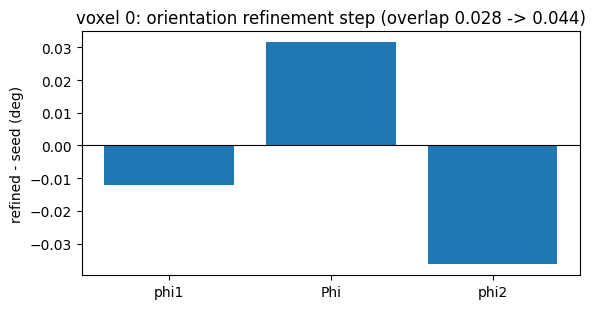

In [7]:
# How far did refinement move the orientation? (per-angle delta, degrees)
delta_deg = np.degrees(box.x.detach().cpu().numpy() - seed_euler.cpu().numpy())
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(['phi1', 'Phi', 'phi2'], delta_deg)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('refined - seed (deg)')
ax.set_title(f'voxel {VOXEL}: orientation refinement step '
             f'(overlap {seed_frac:.3f} -> {fit_frac:.3f})')
plt.tight_layout()
out_png = Path(os.environ.get('TMPDIR', '/tmp')) / 'nf_fitorient_refine.png'
plt.savefig(out_png, dpi=110)
print('saved', out_png)

## 6. The packaged drivers — end-to-end

In production you do not assemble the pieces by hand — you call one of
the three drivers, which run this same screen + L-BFGS machinery over
all voxels (and, for the calibration drivers, jointly refine detector
geometry: per-distance `Lsd`, `BC`, tilts `tx/ty/tz`, `Wedge`).

The two calibration drivers below run **end-to-end on the bundled Au
example, CPU only** — exactly the param file this notebook already
loaded.

```python
from midas_nf_fitorientation import (
    fit_orientation_run,   # per-voxel orientation reconstruction (FitOrientationOMP)
    fit_parameters_run,    # single-voxel geometry calibration (FitOrientationParameters)
    fit_multipoint_run,    # cluster geometry calibration (…MultiPoint)
)
```

The CLI mirrors the C executables:

```bash
midas-nf-fit-orientation params.txt 0 1 4
midas-nf-fit-parameters  params.txt 1
midas-nf-fit-multipoint  params.txt
```

### 6a. Single-voxel calibration — `fit_parameters_run`

Refines one voxel's orientation **jointly** with detector geometry
(per-distance `Lsd`, `BC`, tilts). Internally it does the same
screen + soft-overlap L-BFGS shown above, then a second joint phase that
also lets the geometry move within its tolerances.

In [8]:
from midas_nf_fitorientation import fit_parameters_run

res1 = fit_parameters_run(str(PARAM), voxel_idx=1, n_cpus=4, device='cpu', verbose=False)
print('voxel              :', res1['voxel_idx'])
print('candidates screened:', res1['n_winners'])
print('frac overlap (fit) :', round(res1['frac_overlap'], 4))
print('Euler (deg)        :', np.round(np.degrees(res1['euler_rad']), 3).tolist())
for d in range(p.n_distances):
    print(f'  layer {d}: Lsd={res1["Lsd"][d]:.3f}  '
          f'BC=({res1["y_BC"][d]:.3f}, {res1["z_BC"][d]:.3f})  '
          f'tilts={np.round(res1["tilts"][d], 4).tolist()}')

voxel              : 1
candidates screened: 1
frac overlap (fit) : 0.1335
Euler (deg)        : [-81.674, 44.136, 123.061]
  layer 0: Lsd=8251.117  BC=(985.408, 17.510)  tilts=[0.4776, 0.5852, 0.4871]
  layer 1: Lsd=10252.694  BC=(985.137, 24.511)  tilts=[0.4598, 0.5216, 0.4667]


### 6b. Cluster calibration — `fit_multipoint_run`

Refines **one global geometry** jointly across many voxels — more stable
than single-voxel because the geometry is over-determined. The voxels
come from the param file's `GridPoints` block; when (as here) the param
file has none, the driver derives them from the reconstructed
`MicFileText` `.mic`, keeping the highest-confidence voxels above
`MinConfidence`.

We pass a small `LBFGSConfig` and trim to a handful of voxels here so the
notebook runs quickly; drop both for a full production run.

In [9]:
from midas_nf_fitorientation import fit_multipoint_run
from midas_nf_fitorientation.fit_kernel import LBFGSConfig
from midas_nf_fitorientation.io import read_mic_gridpoints

# Show how GridPoints are derived from the reconstruction when the
# param file carries no explicit block.
mic_path = out_dir / p.mic_file_text
gps = read_mic_gridpoints(mic_path, min_confidence=p.min_confidence, max_points=200)
print(f'derived {len(gps)} GridPoints from {mic_path.name} '
      f'(MinConfidence={p.min_confidence})')

print('sample GridPoint (xc, yc, ud, eul1, eul2, eul3):',
      tuple(round(v, 3) for v in gps[0]))

derived 200 GridPoints from Au_txt_Reconstructed.mic (MinConfidence=0.7)
sample GridPoint (xc, yc, ud, eul1, eul2, eul3): (-11.25, -33.198, -1.0, 4.858, 0.771, 2.15)


In [10]:
# fit_multipoint_run takes a paramfile path. To keep the notebook fast we
# write the param file with a small explicit GridPoints block (4
# high-confidence voxels) to a temp file and run on that; a full run just
# drops the block and lets the driver derive all voxels from the .mic.
import tempfile

with open(PARAM) as f:
    base_param = f.read()
# GridPoints column layout expected by parse_paramfile:
#   GridPoints  d d d d  xc yc  d  ud  eul1 eul2 eul3  d
gp_lines = ''.join(
    f'GridPoints 0 0 0 0 {xc} {yc} 0 {ud} {e1} {e2} {e3} 1\n'
    for (xc, yc, ud, e1, e2, e3) in gps[:4]
)
with tempfile.NamedTemporaryFile('w', suffix='.txt', delete=False, dir=str(SIM)) as tf:
    tf.write(base_param + '\n' + gp_lines)
    tmp_param = tf.name

res2 = fit_multipoint_run(
    tmp_param, n_cpus=4, device='cpu', verbose=False,
    lbfgs_config=LBFGSConfig(max_iter=8, max_outer=8),
)
os.remove(tmp_param)

print('voxels refined  :', len(res2['voxel_eulers_rad']))
print('avg soft overlap:', round(1.0 - res2['loss'], 4))
for d in range(p.n_distances):
    print(f'  layer {d}: Lsd={res2["Lsd"][d]:.3f}  '
          f'BC=({res2["y_BC"][d]:.3f}, {res2["z_BC"][d]:.3f})  '
          f'tilts={np.round(res2["tilts"][d], 4).tolist()}')

/Users/hsharma/opt/MIDAS/packages/midas_nf_fitorientation/midas_nf_fitorientation/fit_multipoint.py:367: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  float(soft_overlap(


voxels refined  : 4
avg soft overlap: 0.4615
  layer 0: Lsd=8284.054  BC=(985.415, 17.510)  tilts=[0.5417, 0.5544, 0.4755]
  layer 1: Lsd=10285.624  BC=(985.160, 24.511)  tilts=[0.5428, 0.5575, 0.4755]


Both calibration drivers now run cleanly end-to-end on the bundled Au
example: `fit_parameters_run` screens + jointly refines a single voxel,
and `fit_multipoint_run` derives its voxel set from the reconstructed
`.mic` (no hand-written `GridPoints` block needed) and refines one global
geometry across them. The refined `Lsd` / `BC` / `tilts` stay within
their configured tolerances of the seed geometry, as expected for a
well-calibrated synthetic example.